## Start Ollama

In [1]:
pip install ollama

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [102]:
import requests

In [103]:
!curl host.docker.internal:11434

Ollama is running

In [104]:
import ollama

client = ollama.Client(host='http://host.docker.internal:11434')

In [105]:
import pandas as pd
from IPython.display import display

import ollama

# Show the whole name of models
pd.set_option('display.max_colwidth', None)

# 1. Fetch the list of local models using the ollama client
try:
    models_data = client.list()
    models_list = models_data.get('models', [])

    if not models_list:
        print("No models found. Make sure Ollama is running and models are downloaded.")
    else:
        # 2. Process the data into a list of dictionaries for pandas
        formatted_list = []
        for model in models_list:
            details = model.get('details', {})
            formatted_list.append({
                'Name': model['model'],
            })

        # 3. Create a pandas DataFrame
        df = pd.DataFrame(formatted_list)

        # 4. Display the DataFrame in the Jupyter notebook (renders as a nice HTML table)
        display(df)

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure the Ollama server is running (run 'ollama serve' in your terminal).")

,Name
0,hf.co/Liyulingyue/PaddleOCR-VL-half-GGUF:Q8_0
1,hf.co/mradermacher/DocTron-Formula-GGUF:Q8_0
2,hf.co/QuantStack/InternVL3_5-8B-gguf:F16
3,hf.co/Mungert/LightOnOCR-1B-1025-GGUF:BF16
4,hf.co/unsloth/Qwen3-VL-4B-Instruct-GGUF:Q4_K_M
5,hf.co/bartowski/Qwen_Qwen2.5-VL-7B-Instruct-GGUF:Q6_K_L
6,hf.co/dinhquangson/MonkeyOCR-pro-1.2B-Vision-GGUF:latest
7,hf.co/bartowski/Qwen2.5-14B-Instruct-GGUF:Q5_K_M
8,hf.co/bartowski/mistralai_Mistral-Small-3.2-24B-Instruct-2506-GGUF:Q5_K_M
9,hf.co/bartowski/Qwen2.5-7B-Instruct-GGUF:Q5_K_M


## Ollama API request functions

In [99]:
import base64

In [97]:
def encode_image(path):
    # Read and encode the image file
    try:
        with open(path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode('utf-8')
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [98]:
def get_response(model, path, content):
    img_b64 = encode_image(path)
    
    response = client.chat(
        model=model,
        messages=[
            {
                "role": "user",
                "content": content,
                "images": [img_b64],  # Base64 image data
            }
        ],
        options={
            'num_ctx': 32768  # Set the context window to 32768 tokens
        },
        stream=False,
    )

    return response["message"]["content"]

In [100]:
content = "Представлено изображение с рукописным русским текстом. \
                Выведи текст с этого изображения без дополнительных комментариев на русском языке."

In [106]:
print(get_response("hf.co/bartowski/Qwen_Qwen2.5-VL-7B-Instruct-GGUF:Q6_K_L",
                   "cyrillic_handwriting_dataset/imgs1000/aa1131.png", content))

Велика


## PaddleOCR-VL request functions

In [7]:
import warnings

warnings.filterwarnings('ignore')

In [47]:
import os
os.environ['GLOG_minloglevel'] = '3'
os.environ['LOGURU_AUTOINIT'] = 'False'

In [176]:
from paddleocr import PaddleOCRVL
paddle = PaddleOCRVL()

In [180]:
def get_responses_batch_paddle(model, images):
    output = pipeline.predict(images)

    responses = []
    for el in output:
        blocks = el['parsing_res_list']
        
        response = "";
        for block in blocks:
            response += block.content + '\n'

        if response is None or len(response) > 4000:  # set hallucination length
            responses.append("Не удалось корректно распознать текст")
        else:
            responses.append(response)

    return responses

In [181]:
print(get_responses_batch_paddle(paddle, "cyrillic_handwriting_dataset/imgs1000/aa1007.png")[0])

нрогацма бодро



## Get responses for series of images

In [62]:
import time

In [182]:
def get_responses(model, images, content):
    responses = []
    for i, image in enumerate(images):
        response = get_response(model, image, content)
        if response is None or len(response) > 4000:  # set hallucination length
            responses.append("Не удалось корректно распознать текст")
        else:
            responses.append(response)

        if not i % 100:
            time.sleep(5)
    return responses

In [186]:
def get_responses_paddle(model, images):
    responses = []
    for i in range(0, 1000, 100):
        response = get_responses_batch_paddle(model, images[i:i + 101])
        responses.extend(response)
        
        time.sleep(5)
    return responses

## Models

In [96]:
qwen_25 = "hf.co/bartowski/Qwen_Qwen2.5-VL-7B-Instruct-GGUF:Q6_K_L"
lighton = "hf.co/Mungert/LightOnOCR-1B-1025-GGUF:BF16"
intern = "hf.co/QuantStack/InternVL3_5-8B-gguf:F16"

## CER, WER computation

In [34]:
!pip install evaluate

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [35]:
pip install jiwer

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [195]:
from evaluate import load
cer = load("cer")
wer = load("wer")

In [196]:
def evaluate_cer_wer(texts, answers):
    total_cer = 0
    total_wer = 0
    
    for i, text in enumerate(texts):
        reference = answers[i]
        
        dif = len(text) - len(reference)
        if dif:
            if dif > 0:
                reference += (' '*dif)
            else:
                text += (' '*(-dif))

        total_cer += cer.compute(references=[reference], predictions=[text])
        total_wer += wer.compute(references=[reference], predictions=[text])

    print(f"CER: {total_cer/(len(texts))}")
    print(f"WER: {total_wer/(len(texts))}")

# Cirillic handwriting dataset

## Choose images

In [20]:
import glob

In [190]:
number_images = 1000 # set number of images to process

In [191]:
images = [file for file in glob.glob('cyrillic_handwriting_dataset/imgs1000/' + '*.png')]
images.sort()
images = images[:number_images]
images[:5]

['cyrillic_handwriting_dataset/imgs1000/aa1.png',
 'cyrillic_handwriting_dataset/imgs1000/aa1007.png',
 'cyrillic_handwriting_dataset/imgs1000/aa101.png',
 'cyrillic_handwriting_dataset/imgs1000/aa1012.png',
 'cyrillic_handwriting_dataset/imgs1000/aa1013.png']

## Get responses for models

In [36]:
qwen_responses = get_responses(qwen_25, images, content)
qwen_responses[:5]

['МОЛОДОВА', 'продолжила борьбу', 'разработанное', 'Бианки', 'Тимир боратын']

In [37]:
intern_responses = get_responses(intern, images, content)
intern_responses[:5]

['Монголия',
 'прогрессивная борьба',
 'КHzraspbomannnoye',
 'Глаза',
 'Евгений Образцов']

In [73]:
lighton_responses = get_responses(lighton, images, content)
lighton_responses[:5]

ResponseError: llama runner process has terminated: exit status 2 (status code: 500)

In [193]:
paddle_responses = get_responses_paddle(paddle, images)
paddle_responses[:5]

['MOMOBA\n', 'нрогацма бодро\n', 'prznałomane\n', '', '']

## Compute CER, WER for models

### Ground truth

In [198]:
import pandas as pd

In [199]:
answers = pd.read_csv('cyrillic_handwriting_dataset/train.tsv', sep='\t', names=["Изображение", "Текст"])
answers.sort_values(by=["Изображение"], inplace = True)
answers.head()

,Изображение,Текст
0,aa1.png,Молдова
1,aa1007.png,продолжила борьбу
2,aa101.png,разработанные
3,aa1012.png,Плачи
4,aa1013.png,Гимны богам


### Metrics for models

#### Qwen 2.5VL

In [42]:
evaluate_cer_wer(qwen_responses, answers["Текст"])

CER: 0.919264115378086
WER: 1.1166666666666667


#### Intern-VL3.5-8B

In [43]:
evaluate_cer_wer(intern_responses, answers["Текст"])

CER: 0.4191190082793026
WER: 0.6786666666666668


#### LightOnOCR-1B 

In [ ]:
evaluate_cer_wer(lighton_responses, answers["Текст"])

#### PaddleOCR-VL

In [200]:
evaluate_cer_wer(paddle_responses, answers["Текст"])

CER: 1.3162628380804495
WER: 1.10802775024777


# Testing dataset

## Test samples

### Visualization

In [69]:
from IPython.display import display, Latex

In [70]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [71]:
def show_source(path, title = None):
    img = mpimg.imread(path)
    imgplot = plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

In [132]:
def show_pair_sources(paths, titles = ("МИЭМ", "Youtube")):
    fig = plt.figure(figsize=(10, 7))

    plt.subplot(1, 2, 1)
    img = mpimg.imread(paths[0])
    imgplot = plt.imshow(img)
    plt.axis('off')
    plt.title(titles[0])
    
    plt.subplot(1, 2, 2)
    img = mpimg.imread(paths[1])
    imgplot = plt.imshow(img)
    plt.axis('off')
    plt.title(titles[1])
    plt.show()

### Cropped formulas

#### Source photos

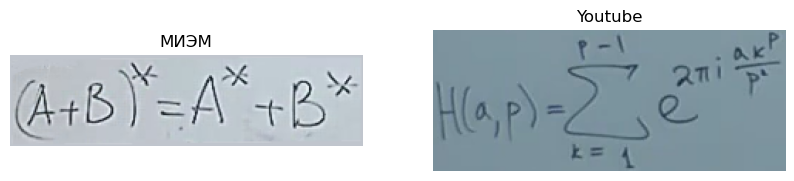

In [130]:
show_pair_sources(["images/formulas_miem_cut.png", "images/formulas_youtube_cut.png"])

#### Prompt

In [56]:
content_formulas = "Представлено изображение с математической формулой. Вывести формулу только в формате Latex без дополнительных комментариев"

#### Qwen 2.5VL

In [143]:
display(Latex(get_responses(qwen_25, ["images/formulas_miem_cut.png"], content_formulas)[0]))

<IPython.core.display.Latex object>

In [144]:
display(Latex(get_responses(qwen_25, ["images/formulas_youtube_cut.png"], content_formulas)[0]))

<IPython.core.display.Latex object>

#### Intern-VL3.5-8B

In [95]:
display(Latex(get_responses(intern, ["images/formulas_miem_cut.png"], content_formulas)[0]))

<IPython.core.display.Latex object>

In [97]:
display(Latex(get_responses(intern, ["images/formulas_youtube_cut.png"], content_formulas)[0]))

<IPython.core.display.Latex object>

#### PaddleOCR-VL

In [72]:
display(Latex(get_responses_paddle(["images/formulas_miem_cut.png"])[0]))

<IPython.core.display.Latex object>

In [74]:
display(Latex(get_responses_paddle(["images/formulas_youtube_cut.png"])[0]))

<IPython.core.display.Latex object>

### Cropped boards

#### Source photos

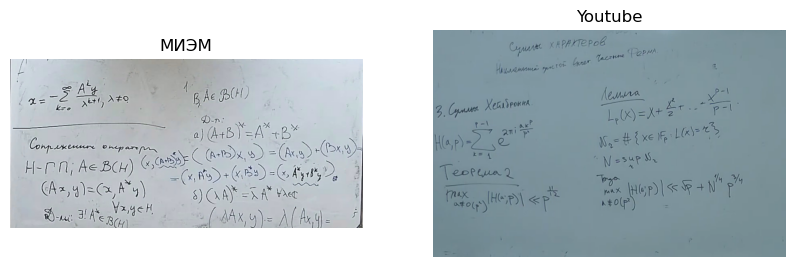

In [133]:
show_pair_sources(["images/formulas_miem_board.png", "images/formulas_youtube_board.png"])

#### Prompt

In [167]:
content_cropped_boards = "Представлено изображение доски с математическими формулами и русским текстом. \
                    Приведи весь текст и формулы с изображения без дополнительных пояснений. \
                    Формулы представь только в формате Latex. Текст представь в формате plain text только на русском языке."

#### Qwen 2.5VL

In [168]:
display(Latex(get_responses(qwen_25, ["images/formulas_miem_board.png"], content_cropped_boards)[0]))

<IPython.core.display.Latex object>

In [171]:
display(Latex(get_responses(qwen_25, ["images/formulas_youtube_board.png"], content_cropped_boards)[0]))

<IPython.core.display.Latex object>

#### Intern-VL3.5-8B

In [174]:
display(Latex(get_responses(intern, ["images/formulas_miem_board.png"], content_cropped_boards)[0]))

<IPython.core.display.Latex object>

In [110]:
display(Latex(get_responses(intern, ["images/formulas_youtube_board.png"], content_cropped_boards)[0]))

<IPython.core.display.Latex object>

#### PaddleOCR-VL

In [75]:
display(Latex(get_responses_paddle(["images/formulas_miem_board.png"])[0]))

<IPython.core.display.Latex object>

In [76]:
display(Latex(get_responses_paddle(["images/formulas_youtube_board.png"])[0]))

<IPython.core.display.Latex object>

### Boards

#### Source photos

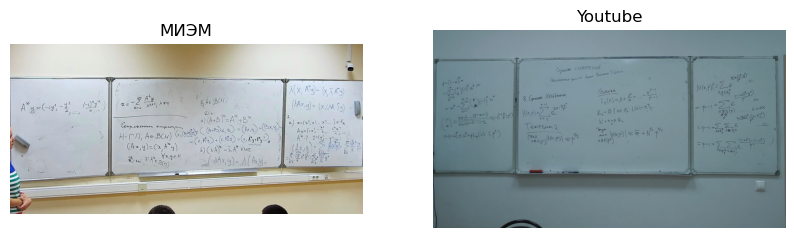

In [162]:
show_pair_sources(["images/formulas_miem.png", "images/formulas_youtube.png"])

#### Prompts

In [322]:
content_boards = "Представлено изображение досок с математическими формулами и русским или английским текстом. \
                    Приведи весь текст и формулы с изображения без дополнительных пояснений. \
                    Формулы представь только в формате Latex. \
                    Текст представь только в формате plain text."

In [245]:
content_boards_ordered = "Представлено изображение трех досок с математическими формулами и русским текстом. \
                    Приведи весь текст и формулы с изображения. \
                    Приведи содержимое каждой доски по отдельности с самой левой доски до самой правой. \
                    Текст и формулы для каждой из досок приведи в естественном порядке. \
                    Не добавляй дополнительных пояснений или комментариев. \
                    Формулы представь только в формате Latex. \
                    Текст представь только в формате plain text только на русском языке."

#### Qwen 2.5VL

##### Unordered prompt

In [256]:
display(Latex(get_responses(qwen_25, ["images/formulas_miem.png"], content_boards)[0]))

<IPython.core.display.Latex object>

In [257]:
display(Latex(get_responses(qwen_25, ["images/formulas_youtube.png"], content_boards)[0]))

<IPython.core.display.Latex object>

##### Ordered prompt

In [249]:
display(Latex(get_responses(qwen_25, ["images/formulas_miem.png"], content_boards_ordered)[0]))

<IPython.core.display.Latex object>

In [250]:
display(Latex(get_responses(qwen_25, ["images/formulas_youtube.png"], content_boards_ordered)[0]))

<IPython.core.display.Latex object>

#### Intern-VL3.5-8B

##### Unordered prompt

In [321]:
display(Latex(get_responses(intern, ["images/formulas_miem.png"], content_boards)[0]))

<IPython.core.display.Latex object>

In [252]:
display(Latex(get_responses(intern, ["images/formulas_youtube.png"], content_boards)[0]))

<IPython.core.display.Latex object>

##### Ordered prompt

In [253]:
display(Latex(get_responses(intern, ["images/formulas_miem.png"], content_boards_ordered)[0]))

<IPython.core.display.Latex object>

In [254]:
display(Latex(get_responses(intern, ["images/formulas_youtube.png"], content_boards_ordered)[0]))

<IPython.core.display.Latex object>

#### PaddleOCR-VL

In [79]:
display(Latex(get_responses_paddle(["images/formulas_miem.png"])[0]))

<IPython.core.display.Latex object>

In [80]:
display(Latex(get_responses_paddle(["images/formulas_youtube.png"])[0]))

<IPython.core.display.Latex object>

## Test subset

### Prompt

In [108]:
content_boards = "Представлено изображение досок с математическими формулами и русским или английским текстом. \
                    Приведи весь текст и формулы с изображения без дополнительных пояснений. \
                    Формулы представь только в формате Latex. \
                    Текст представь только в формате plain text."

### Collect images

In [82]:
images_miem = [file for file in glob.glob('testing_dataset/miem/images/' + '*.png')]
images_miem[:5]

['testing_dataset/miem/images/001.png',
 'testing_dataset/miem/images/002.png',
 'testing_dataset/miem/images/003.png',
 'testing_dataset/miem/images/004.png',
 'testing_dataset/miem/images/005.png']

In [83]:
images_youtube = [file for file in glob.glob('testing_dataset/youtube/images/' + '*.png')]
images_youtube[:5]

['testing_dataset/youtube/images/001.png',
 'testing_dataset/youtube/images/002.png',
 'testing_dataset/youtube/images/023.png',
 'testing_dataset/youtube/images/024.png',
 'testing_dataset/youtube/images/045.png']

### Tests

#### МИЭМ

##### Source photo

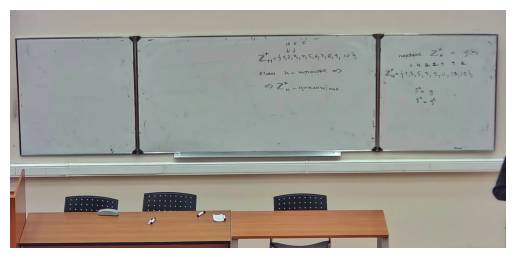

In [268]:
show_source(images_miem[0])

##### Qwen 2.5VL

In [283]:
display(Latex(get_responses(qwen_25, [images_miem[0]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [285]:
display(Latex(get_responses(intern, [images_miem[0]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [84]:
display(Latex(get_responses_paddle([images_miem[0]])[0]))

<IPython.core.display.Latex object>

##### Source photo

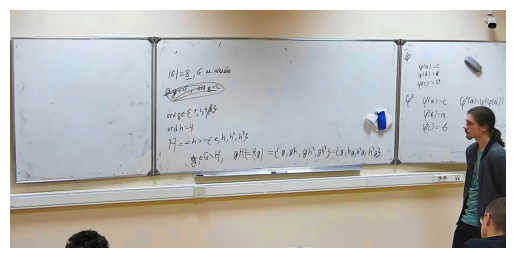

In [270]:
show_source(images_miem[1])

##### Qwen 2.5VL

In [286]:
display(Latex(get_responses(qwen_25, [images_miem[1]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [288]:
display(Latex(get_responses(intern, [images_miem[1]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [85]:
display(Latex(get_responses_paddle([images_miem[1]])[0]))

<IPython.core.display.Latex object>

##### Source photo

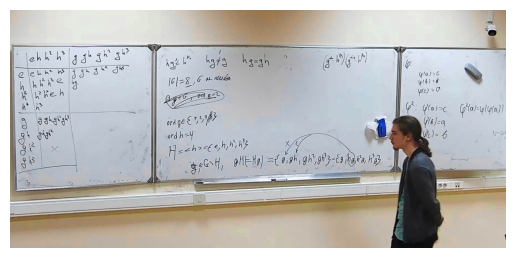

In [271]:
show_source(images_miem[2])

##### Qwen 2.5VL

In [289]:
display(Latex(get_responses(qwen_25, [images_miem[2]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [290]:
display(Latex(get_responses(intern, [images_miem[2]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [86]:
display(Latex(get_responses_paddle([images_miem[2]])[0]))

<IPython.core.display.Latex object>

##### Source photo

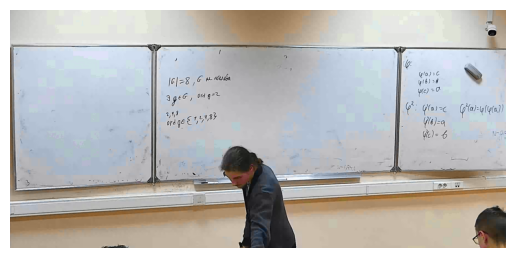

In [272]:
show_source(images_miem[3])

##### Qwen 2.5VL

In [296]:
display(Latex(get_responses(qwen_25, [images_miem[3]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [292]:
display(Latex(get_responses(intern, [images_miem[3]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [87]:
display(Latex(get_responses_paddle([images_miem[3]])[0]))

<IPython.core.display.Latex object>

##### Source photo

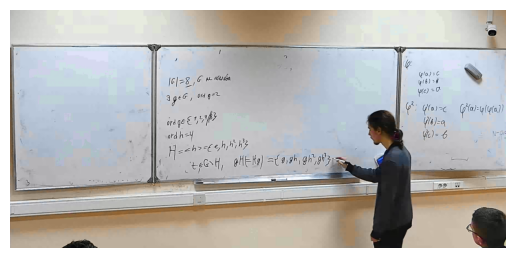

In [273]:
show_source(images_miem[4])

##### Qwen 2.5VL

In [298]:
display(Latex(get_responses(qwen_25, [images_miem[4]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [297]:
display(Latex(get_responses(intern, [images_miem[4]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [88]:
display(Latex(get_responses_paddle([images_miem[4]])[0]))

<IPython.core.display.Latex object>

##### Source photo

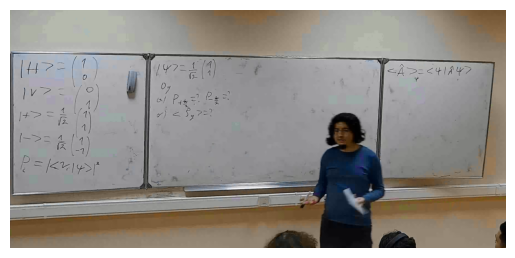

In [274]:
show_source(images_miem[5])

##### Qwen 2.5VL

In [308]:
display(Latex(get_responses(qwen_25, [images_miem[5]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [309]:
display(Latex(get_responses(intern, [images_miem[5]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [89]:
display(Latex(get_responses_paddle([images_miem[5]])[0]))

<IPython.core.display.Latex object>

##### Source photo

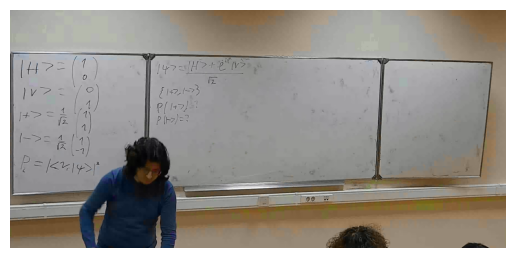

In [310]:
show_source(images_miem[6])

##### Qwen 2.5VL

In [311]:
display(Latex(get_responses(qwen_25, [images_miem[6]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [312]:
display(Latex(get_responses(intern, [images_miem[6]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [90]:
display(Latex(get_responses_paddle([images_miem[6]])[0]))

<IPython.core.display.Latex object>

##### Source photo

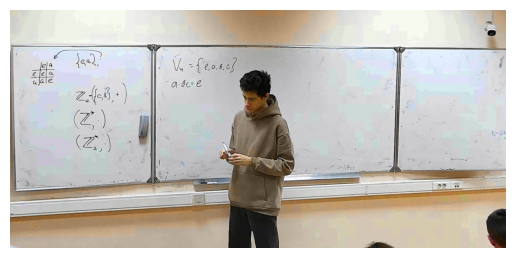

In [276]:
show_source(images_miem[7])

##### Qwen 2.5VL

In [313]:
display(Latex(get_responses(qwen_25, [images_miem[7]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [314]:
display(Latex(get_responses(intern, [images_miem[7]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [91]:
display(Latex(get_responses_paddle([images_miem[7]])[0]))

<IPython.core.display.Latex object>

##### Source photo

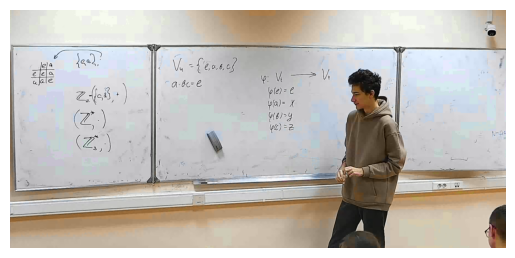

In [277]:
show_source(images_miem[8])

##### Qwen 2.5VL

In [315]:
display(Latex(get_responses(qwen_25, [images_miem[8]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [316]:
display(Latex(get_responses(intern, [images_miem[8]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [92]:
display(Latex(get_responses_paddle([images_miem[8]])[0]))

<IPython.core.display.Latex object>

##### Source photo

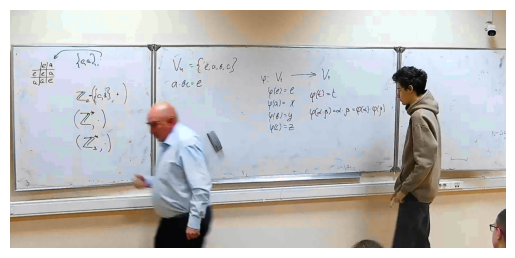

In [278]:
show_source(images_miem[9])

##### Qwen 2.5VL

In [319]:
display(Latex(get_responses(qwen_25, [images_miem[9]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [318]:
display(Latex(get_responses(intern, [images_miem[9]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [93]:
display(Latex(get_responses_paddle([images_miem[9]])[0]))

<IPython.core.display.Latex object>

#### Youtube

##### Source photo

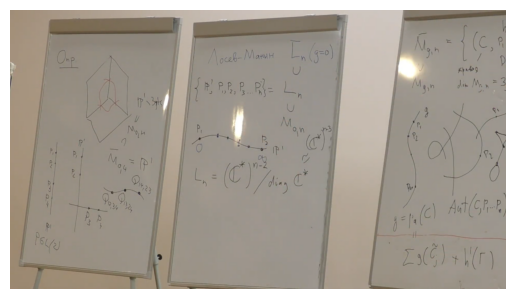

In [324]:
show_source(images_youtube[0])

##### Qwen 2.5VL

In [325]:
display(Latex(get_responses(qwen_25, [images_youtube[0]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [327]:
display(Latex(get_responses(intern, [images_youtube[0]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [94]:
display(Latex(get_responses_paddle([images_youtube[0]])[0]))

<IPython.core.display.Latex object>

##### Source photo

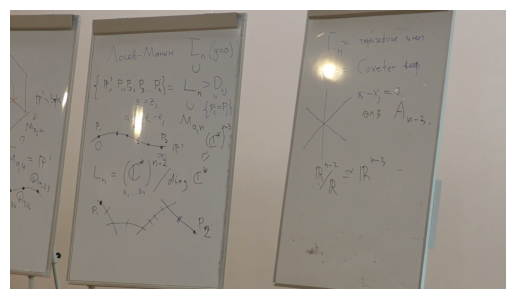

In [328]:
show_source(images_youtube[1])

##### Qwen 2.5VL

In [123]:
display(Latex(get_responses(qwen_25, [images_youtube[1]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [330]:
display(Latex(get_responses(intern, [images_youtube[1]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [ ]:
display(Latex(get_responses_paddle([images_youtube[1]])[0]))

##### Source photo

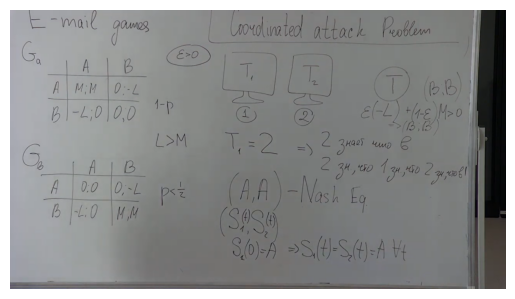

In [331]:
show_source(images_youtube[2])

##### Qwen 2.5VL

In [389]:
display(Latex(get_responses(qwen_25, [images_youtube[2]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [333]:
display(Latex(get_responses(intern, [images_youtube[2]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [112]:
display(Latex(get_responses_paddle([images_youtube[2]])[0]))

<IPython.core.display.Latex object>

##### Source photo

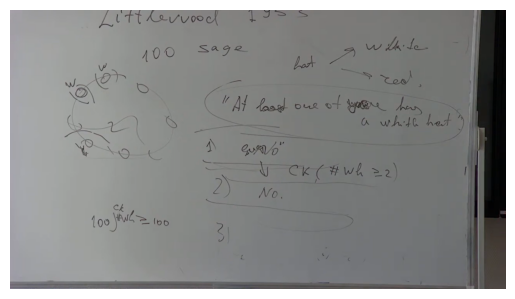

In [335]:
show_source(images_youtube[3])

##### Qwen 2.5VL

In [388]:
display(Latex(get_responses(qwen_25, [images_youtube[3]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [337]:
display(Latex(get_responses(intern, [images_youtube[3]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [113]:
display(Latex(get_responses_paddle([images_youtube[3]])[0]))

<IPython.core.display.Latex object>

##### Source photo

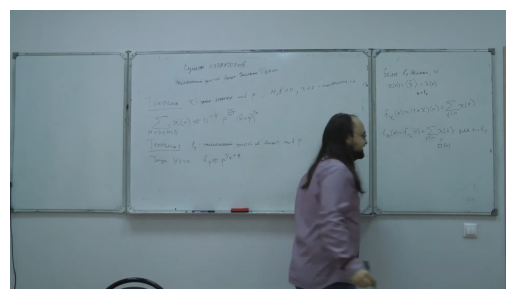

In [340]:
show_source(images_youtube[4])

##### Qwen 2.5VL

In [387]:
display(Latex(get_responses(qwen_25, [images_youtube[4]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [342]:
display(Latex(get_responses(intern, [images_youtube[4]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [114]:
display(Latex(get_responses_paddle([images_youtube[4]])[0]))

<IPython.core.display.Latex object>

##### Source photo

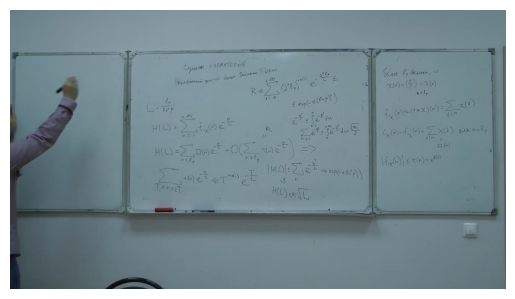

In [347]:
show_source(images_youtube[5])

##### Qwen 2.5VL

In [386]:
display(Latex(get_responses(qwen_25, [images_youtube[5]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [349]:
display(Latex(get_responses(intern, [images_youtube[5]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [115]:
display(Latex(get_responses_paddle([images_youtube[5]])[0]))

<IPython.core.display.Latex object>

##### Source photo

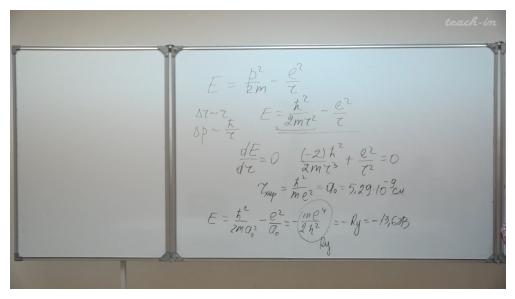

In [352]:
show_source(images_youtube[6])

##### Qwen 2.5VL

In [385]:
display(Latex(get_responses(qwen_25, [images_youtube[6]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [354]:
display(Latex(get_responses(intern, [images_youtube[6]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [116]:
display(Latex(get_responses_paddle([images_youtube[6]])[0]))

<IPython.core.display.Latex object>

##### Source photo

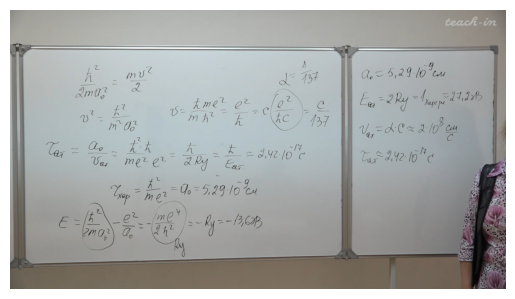

In [355]:
show_source(images_youtube[7])

##### Qwen 2.5VL

In [382]:
display(Latex(get_responses(qwen_25, [images_youtube[7]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [381]:
display(Latex(get_responses(intern, [images_youtube[7]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [117]:
display(Latex(get_responses_paddle([images_youtube[7]])[0]))

<IPython.core.display.Latex object>

##### Source photo

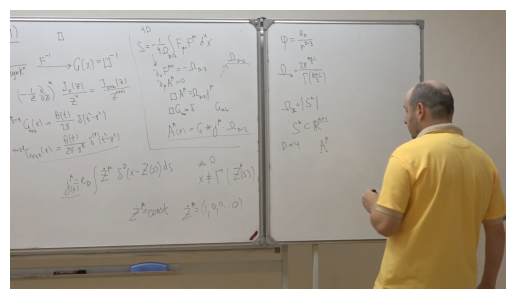

In [358]:
show_source(images_youtube[8])

##### Qwen 2.5VL

In [383]:
display(Latex(get_responses(qwen_25, [images_youtube[8]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [360]:
display(Latex(get_responses(intern, [images_youtube[8]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [118]:
display(Latex(get_responses_paddle([images_youtube[8]])[0]))

<IPython.core.display.Latex object>

##### Source photo

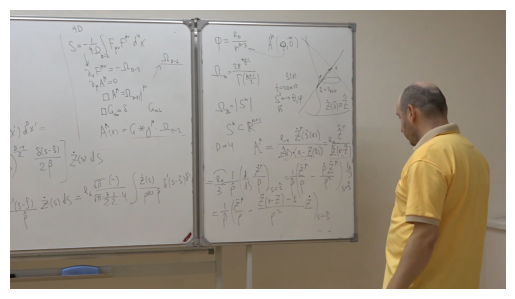

In [362]:
show_source(images_youtube[9])

##### Qwen 2.5VL

In [384]:
display(Latex(get_responses(qwen_25, [images_youtube[9]], content_boards)[0]))

<IPython.core.display.Latex object>

##### Intern-VL3.5-8B

In [390]:
display(Latex(get_responses(intern, [images_youtube[9]], content_boards)[0]))

<IPython.core.display.Latex object>

##### PaddleOCR-VL

In [119]:
display(Latex(get_responses_paddle([images_youtube[9]])[0]))

<IPython.core.display.Latex object>